# Resampling methods

## by Orsolya Bosáková 2.10.2026

### Cross-validation

#### Task 1

We load the data set of polution_cleaneddata.csv and pick out the july temperatures and mortality rates.

In [1]:
import pandas as pd
import numpy as np

# reading in the data
cleandata = pd.read_csv("Data/pollution_cleaneddata.csv")

x_val = cleandata['JULT'].values
y_val = cleandata['MORT'].values

x_val = x_val.reshape(-1,1)


#### Task 2

We will consider two approaches on how to fit a polynomial regression model with degree $p$ that predicts mortality as a function of the average July temperature in degrees $F$.

\begin{equation*}
y_i = \beta_0+\beta_1x_i+\beta_2x_i+\ldots +\beta_px_i^p+\epsilon_i.
\end{equation*}

### Validation set approach

#### Task 3

We do not set the seed overall, but we use the random_state argument within the functions to control the reprodicibility of our results.

#### Task 4

We split the data into two equal parts using train_test_split form skicit-learm's model_selection package. This function divides de data into training and testing based on a specified test_size value, which we choose as $0.5$ for a $50\%$ split.

In [2]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_val, y_val, test_size = 0.5, random_state = 11)


#### Task 5

We make a pipeline to build a chain of the estimators and use the functions PolynomialFeatures(), where we loop through the required degrees $1,2,3,4$, and LinearRegression(), specifying the type of model. We fit the model using our training data and predict on the train and test data. Lastly we calculate the MSE for both the train and the test predictions.


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

degrees = range(1,5)

results = {}

for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression())
    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    results[degree] = {
        "model": model,
        "train_mse": train_mse,
        "test_mse": test_mse
        }

    print(
        f"Degree {degree} | Train MSE: {train_mse:.3f} | Test MSE: {test_mse:.3f}"
    )

Degree 1 | Train MSE: 4347.548 | Test MSE: 2896.456
Degree 2 | Train MSE: 4038.092 | Test MSE: 2711.419
Degree 3 | Train MSE: 3470.305 | Test MSE: 2384.173
Degree 4 | Train MSE: 3462.906 | Test MSE: 2394.846


From the results, we can see that for our specific seed $11$. The train MSE is highest for the degree $1$ polynomial and lowest for the degree $4$ polynomial, showing a gradual decrease of MSE with the increase of the polynomial degree. For the test MSE, the highest values is for degree $1$, just like for the train, but the lowest is for degree $3$, with a slight increase for the degree $4$ polynomial.

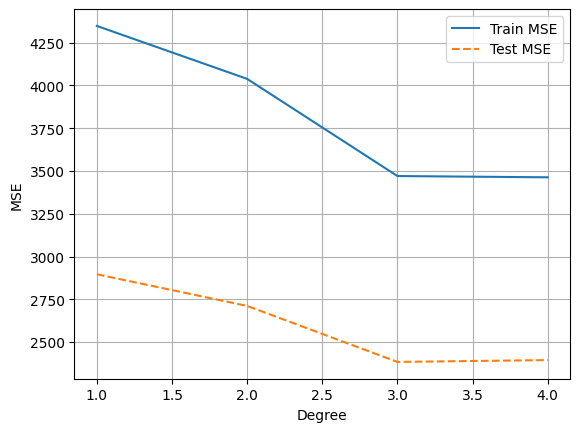

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
x_degrees = list(results.keys())
y_train_mse = [results[degree]["train_mse"] for degree in x_degrees]
y_test_mse = [results[degree]["test_mse"] for degree in x_degrees]
ax.plot(x_degrees, y_train_mse, label="Train MSE")
ax.plot(x_degrees, y_test_mse, label="Test MSE", linestyle="--")
ax.set_xlabel("Degree")
ax.set_ylabel("MSE")
ax.grid()
ax.legend()

We can visualise this in the figure above. Seeing as expexted a continuous decrease for the training MSE. The test MSE looks similar, but if we look closely, we can see the slight increase for degree $4$.

#### Task 6

Judging from the graph, I would recommend the degree $3$ polynomial, due to the dip in test MSE. It could be argues that we should use a lower degree polynomial for the model simplicity, because the difference in test MSE is not extremely striking form degree $1,2,3$. However, a degree $3$ polynomial is stil relatively simple, so this might be more relevant for dicussion if we looked at polynomials of higher degrees as well.

#### Task 7

We repeat the same process as above, but wrap it in an additional for loop to iterate through multiple seed values.

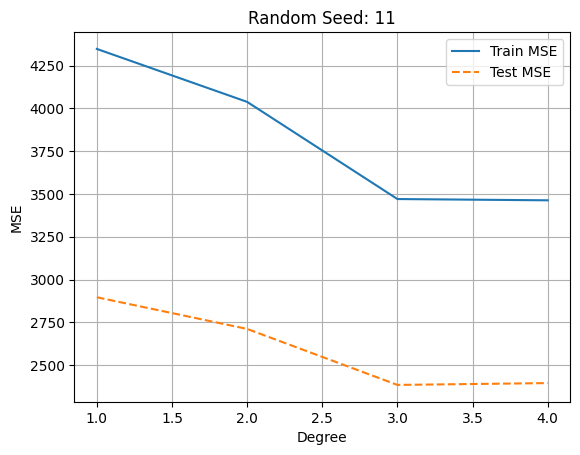

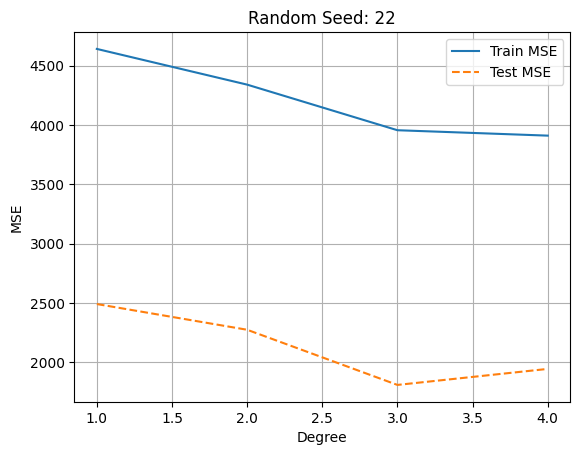

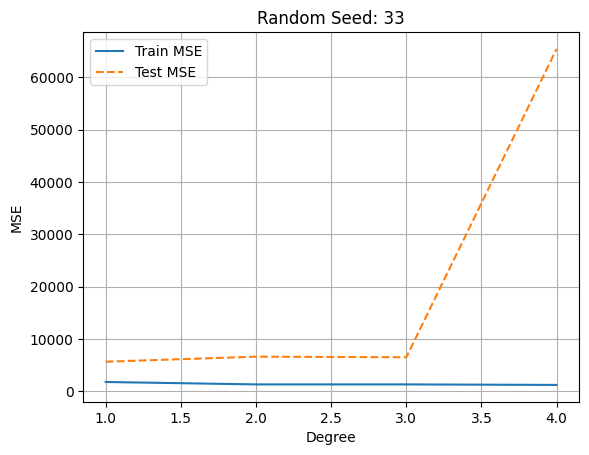

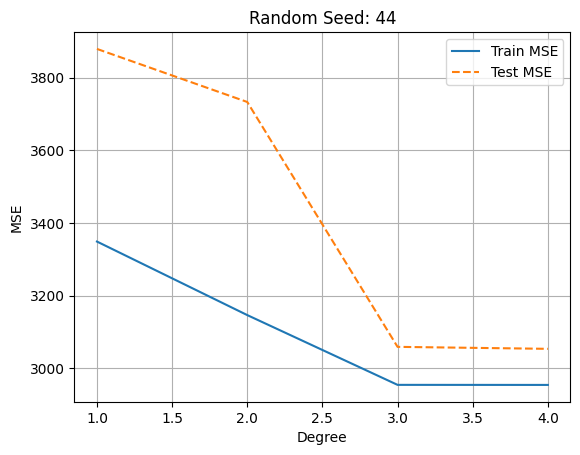

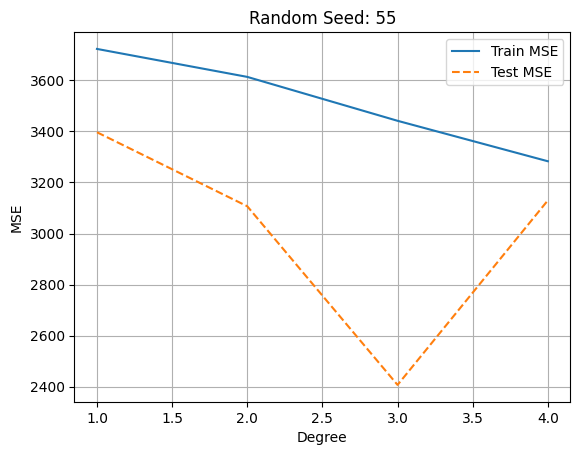

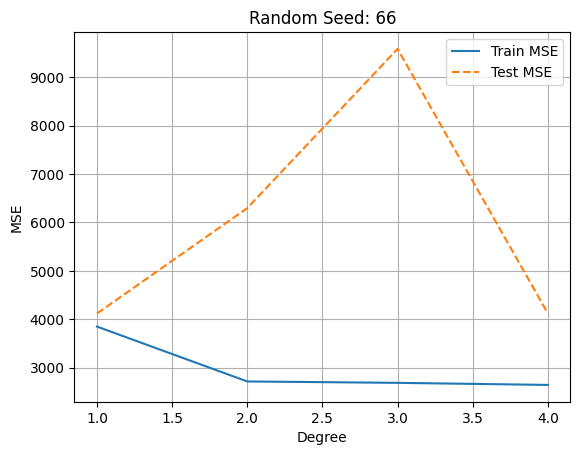

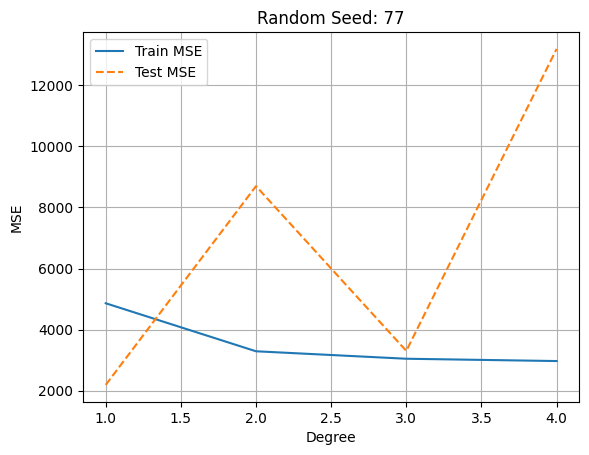

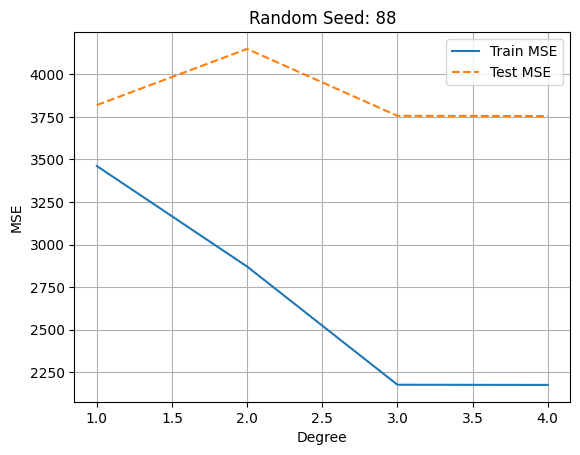

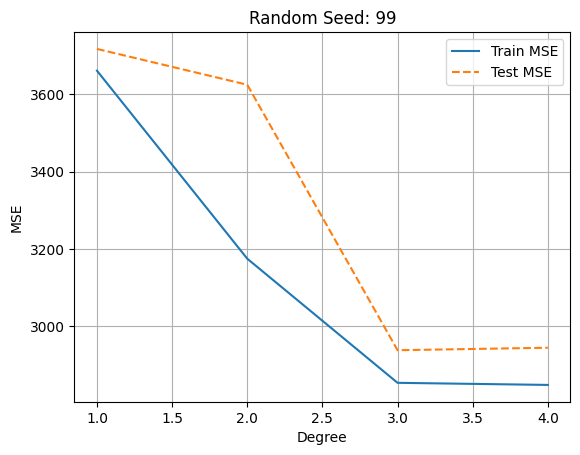

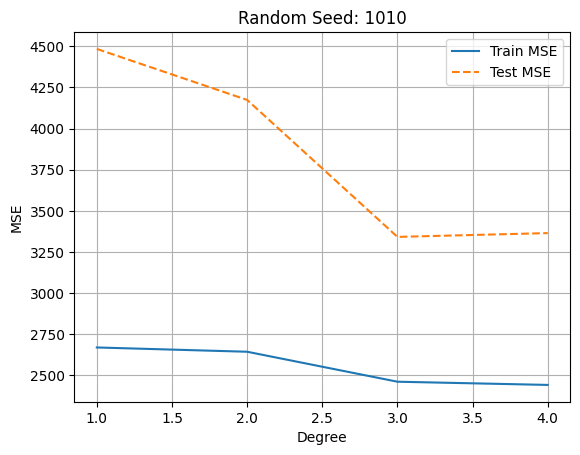

In [5]:
seeds = [11, 22, 33, 44, 55, 66, 77, 88, 99, 1010]

for seed in seeds:
    x_train, x_test, y_train, y_test = train_test_split(x_val, y_val, test_size = 0.5, random_state = seed)

    for degree in degrees:
        model = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression())
        model.fit(x_train, y_train)

        train_pred = model.predict(x_train)
        test_pred = model.predict(x_test)

        train_mse = mean_squared_error(y_train, train_pred)
        test_mse = mean_squared_error(y_test, test_pred)

        results[degree] = {
            "model": model,
            "train_mse": train_mse,
            "test_mse": test_mse
            }

    fig, ax = plt.subplots()
    x_degrees = list(results.keys())
    y_train_mse = [results[degree]["train_mse"] for degree in x_degrees]
    y_test_mse = [results[degree]["test_mse"] for degree in x_degrees]
    ax.plot(x_degrees, y_train_mse, label="Train MSE")
    ax.plot(x_degrees, y_test_mse, label="Test MSE", linestyle="--")
    ax.set_xlabel("Degree")
    ax.set_ylabel("MSE")
    ax.set_title(f"Random Seed: {seed}")
    ax.grid()
    ax.legend()

We can see that for different seed values, we can get very different train and test MSEs. I would like to put them in two general cathegories: 
 - Seeds where train MSE is greater than test MSE (mostly): 11, 22, 55;
 - Seeds where test MSE is greater than train MSE (mostly): 33, 44, 66, 77, 88, 99, 1010.
 
When we look at the most optimal degrees for a polynomial from this set, we see that for the train MSE, almost always (seed 44 is debatable) a degree $4$ polynomial gives the best result. For the test MSE it is more varied across seeds, 5 out of 10 times it is a degree $3$ polynomial, but degree $1$ and $4$ also show up as the best MSE result. Overall, the observation would be not to take a degree $2$ polynomial for the model, but rather a $3$ or $4$. In my case, I will continue with a degree $3$ polynomial, because that seemed to be most consistent for the test MSE values.

#### Task 8

We fit a new model using K-fold cross-validation, with a polynomial of degree $3$, as justified above, and $K=3$. We use the KFold function, specify that we want exactly $3$ splits in the data, we shuffle the data before splitting it and set a random seed to $11$. Then we split our training data and fit the model to each split, predict for both test and train and save the values. Lastly, we calculate the mean of the variance across each split.

In [6]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=3, shuffle=True, random_state=11)

model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())

predictions_train = []
predictions_test = []

for train_indices, test_indices in kf.split(x_train):
    x_tr, y_tr = x_train[train_indices], y_train[train_indices]
    model.fit(x_tr, y_tr)
    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)
    predictions_train.append(train_pred)
    predictions_test.append(test_pred)

prediction_train = np.array(predictions_train)
prediction_test = np.array(predictions_test)

train_pred_var = np.var(prediction_train, axis=0)
test_pred_var = np.var(prediction_test, axis=0)

mean_var_train = np.mean(train_pred_var)
mean_var_test = np.mean(test_pred_var)

print(f"Mean variance of train predictions: {mean_var_train:.3f}")
print(f"Mean variance of test predictions: {mean_var_test:.3f}")


Mean variance of train predictions: 110.834
Mean variance of test predictions: 153.944


We get that the mean of the variance for the train predictions is lower than for teh test predictions. This is to be expected, because the model was trained on the train samples and it should have a larger variance when it comes to unseen samples.

#### Task 9

We repeat the same task as above, but with other seeds.

In [7]:
for seed in seeds:
    kf = KFold(n_splits=3, shuffle=True, random_state=seed)

    model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())

    predictions_train = []
    predictions_test = []

    for train_indices, test_indices in kf.split(x_train):
        x_tr, y_tr = x_train[train_indices], y_train[train_indices]
        model.fit(x_tr, y_tr)
        train_pred = model.predict(x_train)
        test_pred = model.predict(x_test)
        predictions_train.append(train_pred)
        predictions_test.append(test_pred)

    prediction_train = np.array(predictions_train)
    prediction_test = np.array(predictions_test)

    train_pred_var = np.var(prediction_train, axis=0)
    test_pred_var = np.var(prediction_test, axis=0)

    mean_var_train = np.mean(train_pred_var)
    mean_var_test = np.mean(test_pred_var)

    print(f"Random Seed: {seed} | Mean variance of train predictions: {mean_var_train:.3f} | Mean variance of test predictions: {mean_var_test:.3f}")

Random Seed: 11 | Mean variance of train predictions: 110.834 | Mean variance of test predictions: 153.944
Random Seed: 22 | Mean variance of train predictions: 61.678 | Mean variance of test predictions: 114.965
Random Seed: 33 | Mean variance of train predictions: 465.874 | Mean variance of test predictions: 772.338
Random Seed: 44 | Mean variance of train predictions: 431.942 | Mean variance of test predictions: 578.194
Random Seed: 55 | Mean variance of train predictions: 233.427 | Mean variance of test predictions: 524.002
Random Seed: 66 | Mean variance of train predictions: 1488.168 | Mean variance of test predictions: 2837.532
Random Seed: 77 | Mean variance of train predictions: 30.099 | Mean variance of test predictions: 35.353
Random Seed: 88 | Mean variance of train predictions: 235.035 | Mean variance of test predictions: 336.853
Random Seed: 99 | Mean variance of train predictions: 670.197 | Mean variance of test predictions: 1681.673
Random Seed: 1010 | Mean variance of 

We can see that we get quite a wide variety of mean variances across different seeds. For the train predictions, the lowest mean variance values is $30.099$ for seed $77$, and the highest is $1488.168$ for seed $66$. For the test predictions, the lowest value is $35.353$ for seed $77$, and the highest is $2837.532$ for seed $66$. What we can observe here is that if we only rely on one randomly chosen seed, we can get skewed results, so I would suggest using a larger amount of random seeds and averaging the MSE values for them to get more accurate results.

#### Task 10

We load the bird_count.csv file from Project 2.

In [8]:
bird_data = pd.read_csv("Data/bird_count.csv")

#### Task 11

We copy the Poisson distribution function from Project 2, but we alter it sligthly for the $\hat{\beta_1}$ calculations. Recode it as a function to be able to call it withing scipy's bootstrap function.

In [9]:
#from project 2 altered a bit
import scipy as sc

def nll_Poisson(params, x, y):
    '''The negative log likelihood function for poisson 
    distribution, that takes three arguments, params with is an array
    of two elements, x and y which are the independent and 
    dependent variables respectively, and returns the negative 
    log likelihood value.'''
    beta0, beta1 = params #unpacking the parameters

    #calculating the negative log likelihood value
    term_1 = y * (beta0 + beta1 * x)
    term_2 = np.exp(beta0 + beta1 * x)
    term_3 = np.log(sc.special.factorial(y))
    nll = np.sum(- term_1 + term_2 + term_3)

    return nll

#separating the independent and dependent variables
years = bird_data["yr"].values
y_val = bird_data["count"].values

#adjusting the years to start from 0
x_val = years - years[0]

def get_beta1_hat(x, y):
    #initial guess for the parameters of the poisson distribution
    params = [0.0, 0.0]

    #fitting the poisson regression model using maximum likelihood estimation
    max_likelihood = sc.optimize.minimize(nll_Poisson, params, args=(x, y))

    return max_likelihood.x[1] #returning the estimated value of beta1

#unpacking the estimated parameters from the optimization result
beta1_hat = get_beta1_hat(x_val, y_val)

print("Beta 1 (Slope) estimate:",beta1_hat)

Beta 1 (Slope) estimate: -0.03244318679983951


The $\hat{\beta_1}$ estimator matches the one given in the assigment, so we can continue.

#### Task 12

We implement the bootstrap using scipy.stats's function, where we specify the data that we use, the function that calculates the $\hat{\beta_1}$ values, that the $(x_i, y_i)$ pairs should remain in pairs, the method to be percentile. This means that it will calculate the interval of the bootstrap distribution that is symmetric about the median and contains confidence level of the resampled statistic values. We, again, also set a random seed, or state in this case, for reproducibility. 

In [10]:
from scipy.stats import bootstrap

res = bootstrap((x_val, y_val), get_beta1_hat, paired = True, method='percentile', random_state = 11)

standard_error = res.standard_error
ci = res.confidence_interval

We show the resulting standard error and plot it in the style of a histogram.

Standard error of Beta 1 (Slope): 0.0342306297590395


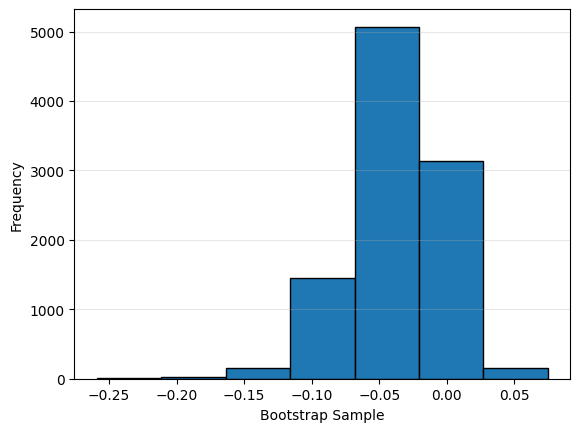

In [11]:
print("Standard error of Beta 1 (Slope):", standard_error)

plt.hist(res.bootstrap_distribution, bins=7, edgecolor='black')
plt.xlabel("Bootstrap Sample")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

We can see that the standard error of the slope $\hat{\beta_1}$ is approximately $0.03423$, which is slightly different than the value given in the assigment. This difference in the value and also in the histogram could be due to the difference in implementation or due to a differents seed.